In [1]:
!pip install mysql-connector-python

In [2]:
import mysql.connector
import pandas as pd

In [4]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sourabh@121076",
    database="ridepulse"
)

print("MySQL connection successful!")

MySQL connection successful!


In [5]:
query = """
SELECT *
FROM ride_bookings
LIMIT 10;
"""

df_sql = pd.read_sql(query, conn)

df_sql.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\264175914.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, conn)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,0 days 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,None,None,None,None,None,NaN,NaN,NaN,NaN,None
1,2024-11-29,0 days 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,None,None,None,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,0 days 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,None,None,None,None,None,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,0 days 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,None,None,None,None,None,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,0 days 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,None,None,None,None,None,737.0,48.21,4.1,4.3,UPI


In [6]:
df_sql.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [7]:
# Q1: Overall Business Performance
# Business Question:
# What is the overall performance of RidePulse in terms
# of bookings, completed rides, cancellations, and revenue?

query_q1 = """
SELECT
    COUNT(*) AS total_bookings,

    SUM(
        CASE
            WHEN `Booking Status` = 'Completed'
            THEN 1
            ELSE 0
        END
    ) AS completed_rides,

    SUM(
        CASE
            WHEN `Booking Status` LIKE '%Cancel%'
            THEN 1
            ELSE 0
        END
    ) AS cancelled_rides,

    SUM(`Booking Value`) AS total_booking_value

FROM ride_bookings;
"""

q1_result = pd.read_sql(query_q1, conn)

q1_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\146132234.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q1_result = pd.read_sql(query_q1, conn)


,total_bookings,completed_rides,cancelled_rides,total_booking_value
0,22600,13999.0,5587.0,7818756.0


In [8]:
# Calculate completion and cancellation percentages

total = q1_result.loc[0, "total_bookings"]

q1_result["completion_rate_%"] = round(
    q1_result.loc[0, "completed_rides"] / total * 100, 2
)

q1_result["cancellation_rate_%"] = round(
    q1_result.loc[0, "cancelled_rides"] / total * 100, 2
)

q1_result

,total_bookings,completed_rides,cancelled_rides,total_booking_value,completion_rate_%,cancellation_rate_%
0,22600,13999.0,5587.0,7818756.0,61.94,24.72


In [9]:
# Q2: Booking Status Distribution
# Business Question:
# How are bookings distributed across different
# booking statuses?

query_q2 = """
SELECT
    `Booking Status`,
    COUNT(*) AS total_bookings,

    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM ride_bookings),
        2
    ) AS booking_percentage

FROM ride_bookings

GROUP BY `Booking Status`

ORDER BY total_bookings DESC;
"""

q2_result = pd.read_sql(query_q2, conn)

q2_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\529478670.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q2_result = pd.read_sql(query_q2, conn)


,Booking Status,total_bookings,booking_percentage
0,Completed,13999,61.94
1,Cancelled by Driver,3999,17.69
2,No Driver Found,1617,7.15
3,Cancelled by Customer,1588,7.03
4,Incomplete,1397,6.18


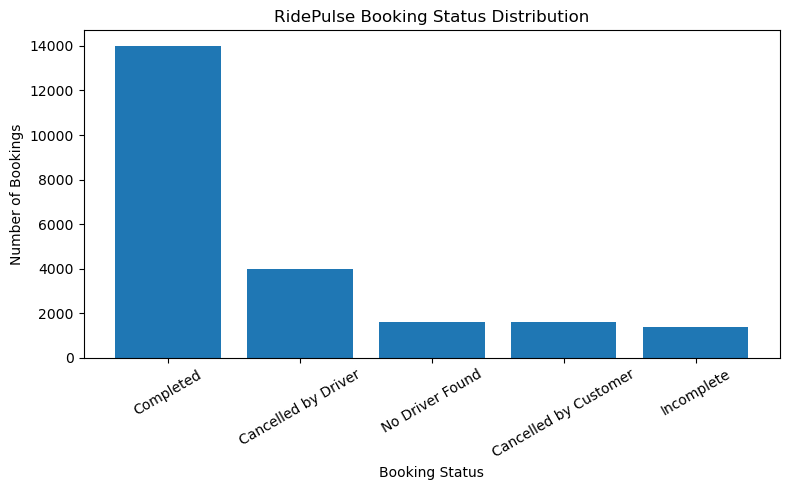

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    q2_result["Booking Status"],
    q2_result["total_bookings"]
)

plt.title("RidePulse Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# Q3: Vehicle Performance
# Business Question:
# Which vehicle types generate the highest number
# of bookings and booking value?

query_q3 = """
SELECT
    `Vehicle Type`,
    COUNT(*) AS total_bookings,
    SUM(`Booking Value`) AS total_booking_value,
    ROUND(AVG(`Booking Value`), 2) AS average_booking_value

FROM ride_bookings

GROUP BY `Vehicle Type`

ORDER BY total_booking_value DESC;
"""

q3_result = pd.read_sql(query_q3, conn)

q3_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\953256822.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q3_result = pd.read_sql(query_q3, conn)


,Vehicle Type,total_bookings,total_booking_value,average_booking_value
0,Auto,5605,1921733.0,502.94
1,Go Mini,4576,1575671.0,502.93
2,Go Sedan,4133,1434768.0,515.73
3,Bike,3330,1186203.0,526.03
4,Premier Sedan,2731,939111.0,502.20
5,eBike,1584,547484.0,499.99
6,Uber XL,641,213786.0,485.88


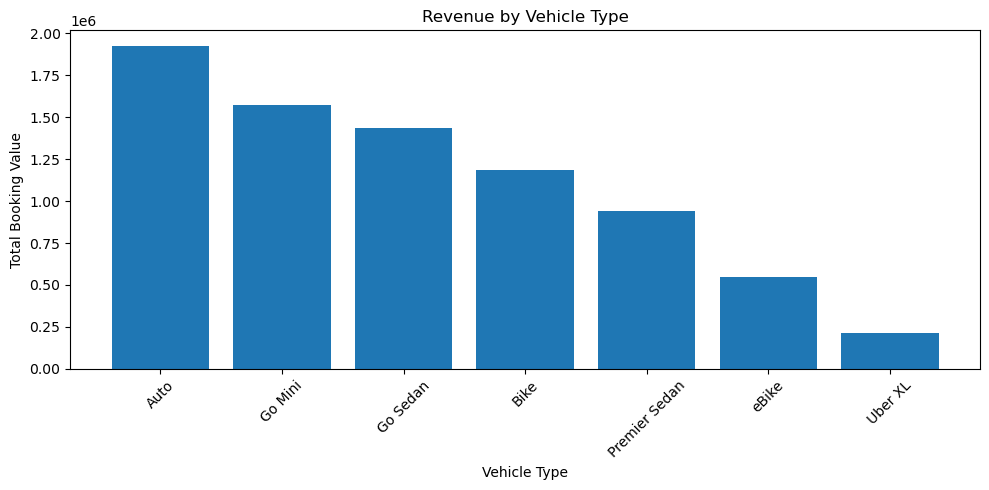

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    q3_result["Vehicle Type"],
    q3_result["total_booking_value"]
)

plt.title("Revenue by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Booking Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Q4: Cancellation Analysis
# Business Question:
# How many rides were cancelled by customers
# versus drivers?

query_q4 = """
SELECT
    `Booking Status`,
    COUNT(*) AS cancelled_rides

FROM ride_bookings

WHERE `Booking Status` LIKE '%Cancel%'

GROUP BY `Booking Status`

ORDER BY cancelled_rides DESC;
"""

q4_result = pd.read_sql(query_q4, conn)

q4_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\1787707510.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q4_result = pd.read_sql(query_q4, conn)


,Booking Status,cancelled_rides
0,Cancelled by Driver,3999
1,Cancelled by Customer,1588


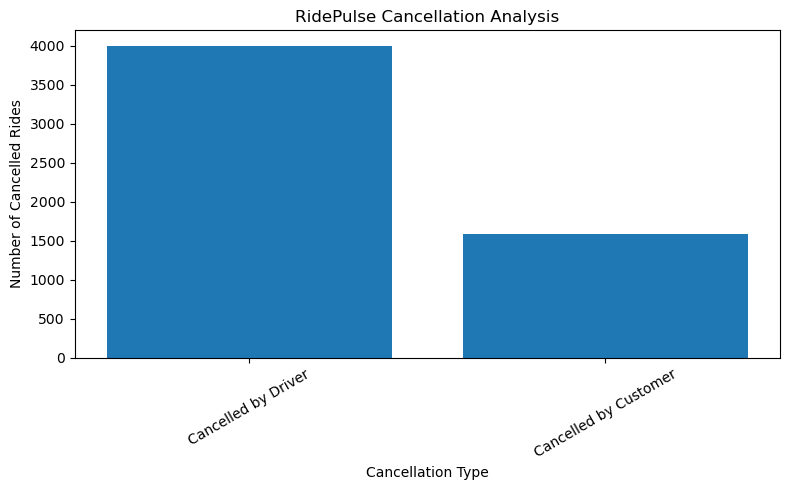

In [14]:
# Visualize cancellation distribution

plt.figure(figsize=(8, 5))

plt.bar(
    q4_result["Booking Status"],
    q4_result["cancelled_rides"]
)

plt.title("RidePulse Cancellation Analysis")
plt.xlabel("Cancellation Type")
plt.ylabel("Number of Cancelled Rides")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [15]:
# Q5: Customer Cancellation Reasons

query_q5 = """
SELECT
    `Reason for cancelling by Customer` AS cancellation_reason,
    COUNT(*) AS cancellation_count

FROM ride_bookings

WHERE `Reason for cancelling by Customer` IS NOT NULL
  AND `Reason for cancelling by Customer` <> ''

GROUP BY `Reason for cancelling by Customer`

ORDER BY cancellation_count DESC;
"""

q5_result = pd.read_sql(query_q5, conn)

q5_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\3161272914.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q5_result = pd.read_sql(query_q5, conn)


,cancellation_reason,cancellation_count
0,Change of plans,381
1,Wrong Address,373
2,Driver is not moving towards pickup location,347
3,Driver asked to cancel,323
4,AC is not working,164


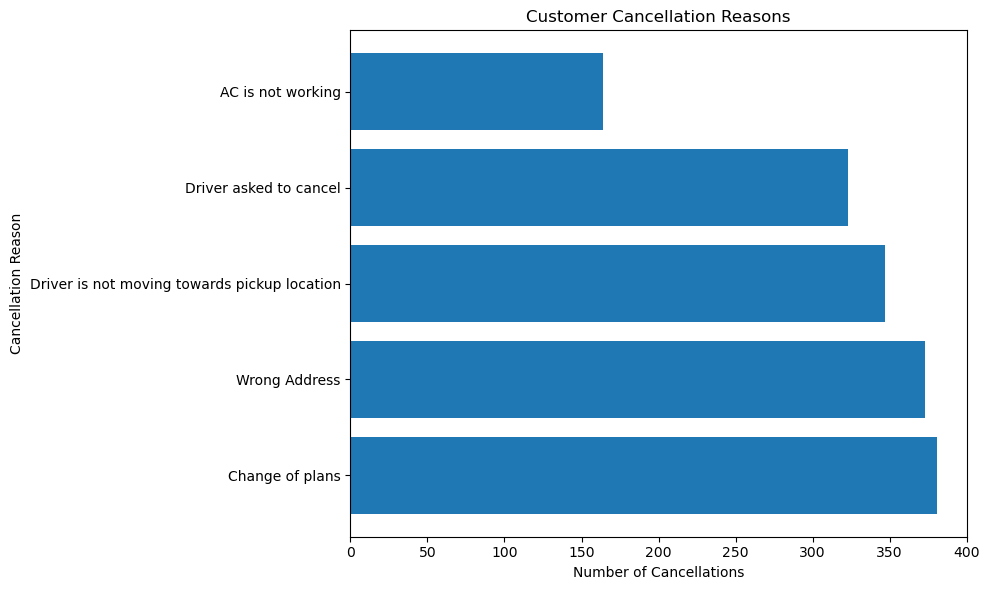

In [16]:
# Q5 Visualization

plt.figure(figsize=(10, 6))

plt.barh(
    q5_result["cancellation_reason"],
    q5_result["cancellation_count"]
)

plt.title("Customer Cancellation Reasons")
plt.xlabel("Number of Cancellations")
plt.ylabel("Cancellation Reason")

plt.tight_layout()
plt.show()

In [17]:
# Q6: Payment Method Analysis

query_q6 = """
SELECT
    `Payment Method`,
    COUNT(*) AS total_bookings,
    SUM(`Booking Value`) AS total_booking_value,
    ROUND(AVG(`Booking Value`), 2) AS average_booking_value

FROM ride_bookings

WHERE `Payment Method` IS NOT NULL
  AND `Payment Method` <> ''

GROUP BY `Payment Method`

ORDER BY total_booking_value DESC;
"""

q6_result = pd.read_sql(query_q6, conn)

q6_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\1180193015.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q6_result = pd.read_sql(query_q6, conn)


,Payment Method,total_bookings,total_booking_value,average_booking_value
0,UPI,6967,3544316.0,508.73
1,Cash,3867,1937185.0,500.95
2,Uber Wallet,1836,940576.0,512.30
3,Credit Card,1489,763069.0,512.47
4,Debit Card,1237,633610.0,512.22


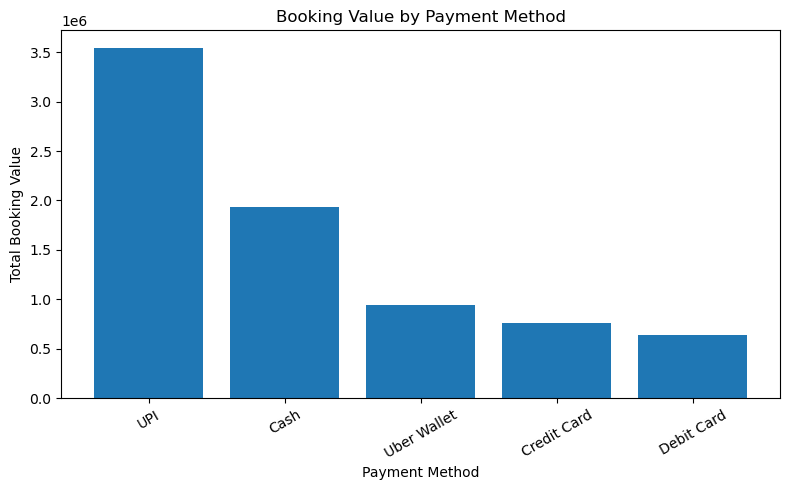

In [18]:
# Q6 Visualization

plt.figure(figsize=(8, 5))

plt.bar(
    q6_result["Payment Method"],
    q6_result["total_booking_value"]
)

plt.title("Booking Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Booking Value")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [19]:
# Q7: Ride Distance by Vehicle Type

query_q7 = """
SELECT
    `Vehicle Type`,
    COUNT(*) AS total_rides,
    ROUND(AVG(`Ride Distance`), 2) AS average_ride_distance,
    ROUND(MAX(`Ride Distance`), 2) AS maximum_ride_distance

FROM ride_bookings

WHERE `Ride Distance` IS NOT NULL

GROUP BY `Vehicle Type`

ORDER BY average_ride_distance DESC;
"""

q7_result = pd.read_sql(query_q7, conn)

q7_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\1374748136.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q7_result = pd.read_sql(query_q7, conn)


,Vehicle Type,total_rides,average_ride_distance,maximum_ride_distance
0,Uber XL,440,25.21,49.98
1,Auto,3821,25.06,49.98
2,Bike,2255,24.97,49.97
3,eBike,1095,24.95,49.97
4,Premier Sedan,1870,24.78,49.98
5,Go Mini,3133,24.67,49.99
6,Go Sedan,2782,24.58,50.00


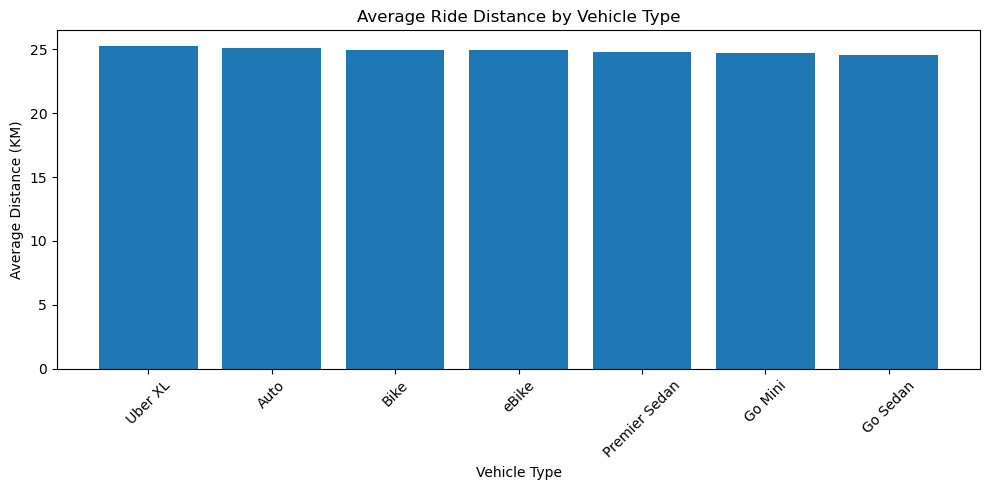

In [20]:
# Q7 Visualization

plt.figure(figsize=(10, 5))

plt.bar(
    q7_result["Vehicle Type"],
    q7_result["average_ride_distance"]
)

plt.title("Average Ride Distance by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Distance (KM)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Q8: High-Demand Vehicle Types
# SQL Concept: HAVING

query_q8 = """
SELECT
    `Vehicle Type`,
    COUNT(*) AS total_bookings,
    ROUND(AVG(`Booking Value`), 2) AS average_booking_value

FROM ride_bookings

GROUP BY `Vehicle Type`

HAVING COUNT(*) > 1000

ORDER BY total_bookings DESC;
"""

q8_result = pd.read_sql(query_q8, conn)

q8_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\2897138483.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q8_result = pd.read_sql(query_q8, conn)


,Vehicle Type,total_bookings,average_booking_value
0,Auto,5605,502.94
1,Go Mini,4576,502.93
2,Go Sedan,4133,515.73
3,Bike,3330,526.03
4,Premier Sedan,2731,502.20
5,eBike,1584,499.99


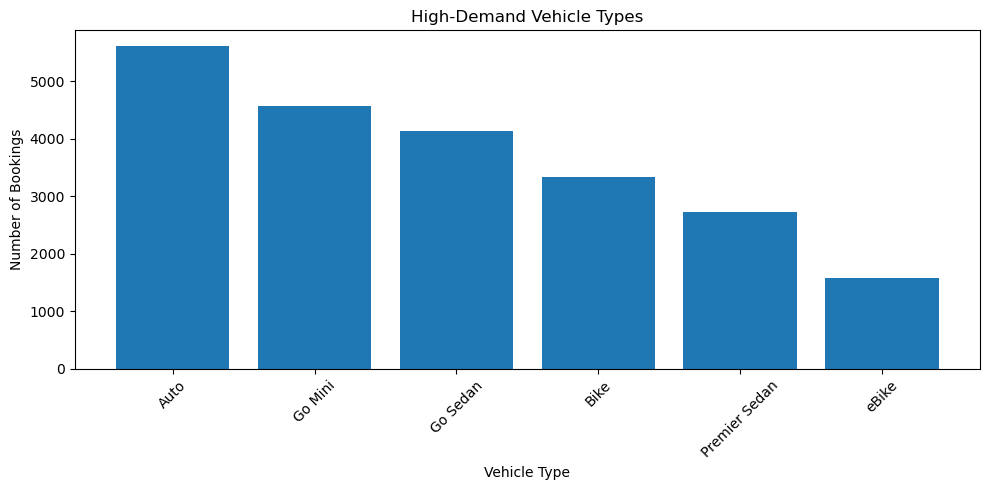

In [22]:
# Q8 Visualization

plt.figure(figsize=(10, 5))

plt.bar(
    q8_result["Vehicle Type"],
    q8_result["total_bookings"]
)

plt.title("High-Demand Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Q9: Monthly Revenue Trend

query_q9 = """
SELECT
    DATE_FORMAT(`Date`, '%Y-%m') AS month,
    COUNT(*) AS total_bookings,
    SUM(`Booking Value`) AS monthly_booking_value

FROM ride_bookings

GROUP BY DATE_FORMAT(`Date`, '%Y-%m')

ORDER BY month;
"""

q9_result = pd.read_sql(query_q9, conn)

q9_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\464653679.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q9_result = pd.read_sql(query_q9, conn)


,month,total_bookings,monthly_booking_value
0,2024-01,1840,646953.0
1,2024-02,1805,616021.0
2,2024-03,1860,681003.0
3,2024-04,1835,636174.0
4,2024-05,1997,667767.0
5,2024-06,1810,628545.0
6,2024-07,1984,679368.0
7,2024-08,1922,647388.0
8,2024-09,1866,638386.0
9,2024-10,1910,678353.0


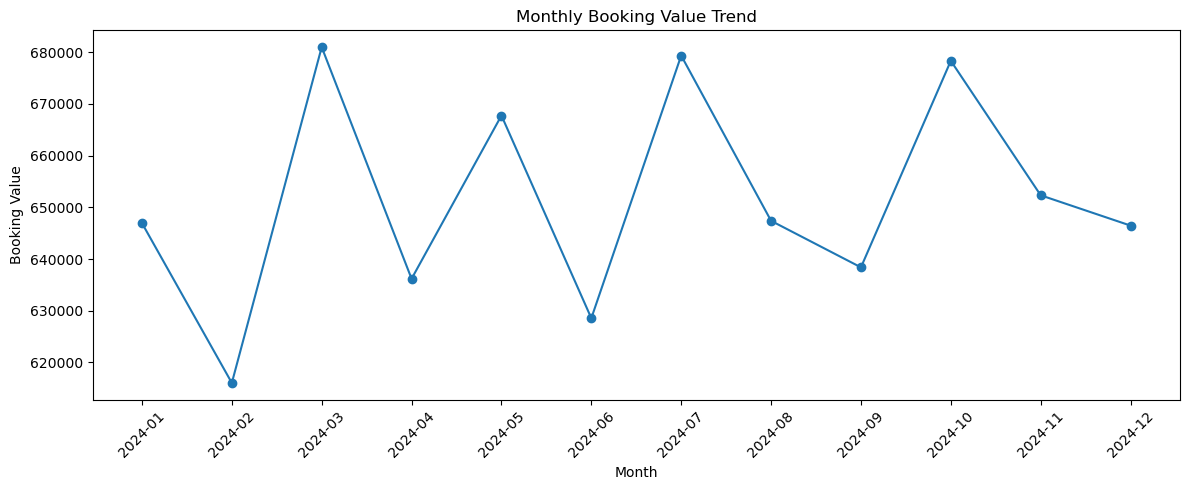

In [24]:
# Q9 Visualization

plt.figure(figsize=(12, 5))

plt.plot(
    q9_result["month"],
    q9_result["monthly_booking_value"],
    marker="o"
)

plt.title("Monthly Booking Value Trend")
plt.xlabel("Month")
plt.ylabel("Booking Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
# Q10: Vehicle Ranking by Booking Value
# SQL Concept: RANK() Window Function

query_q10 = """
SELECT
    `Vehicle Type`,
    SUM(`Booking Value`) AS total_booking_value,

    RANK() OVER (
        ORDER BY SUM(`Booking Value`) DESC
    ) AS revenue_rank

FROM ride_bookings

GROUP BY `Vehicle Type`

ORDER BY revenue_rank;
"""

q10_result = pd.read_sql(query_q10, conn)

q10_result

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27456\1511749263.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  q10_result = pd.read_sql(query_q10, conn)


,Vehicle Type,total_booking_value,revenue_rank
0,Auto,1921733.0,1
1,Go Mini,1575671.0,2
2,Go Sedan,1434768.0,3
3,Bike,1186203.0,4
4,Premier Sedan,939111.0,5
5,eBike,547484.0,6
6,Uber XL,213786.0,7


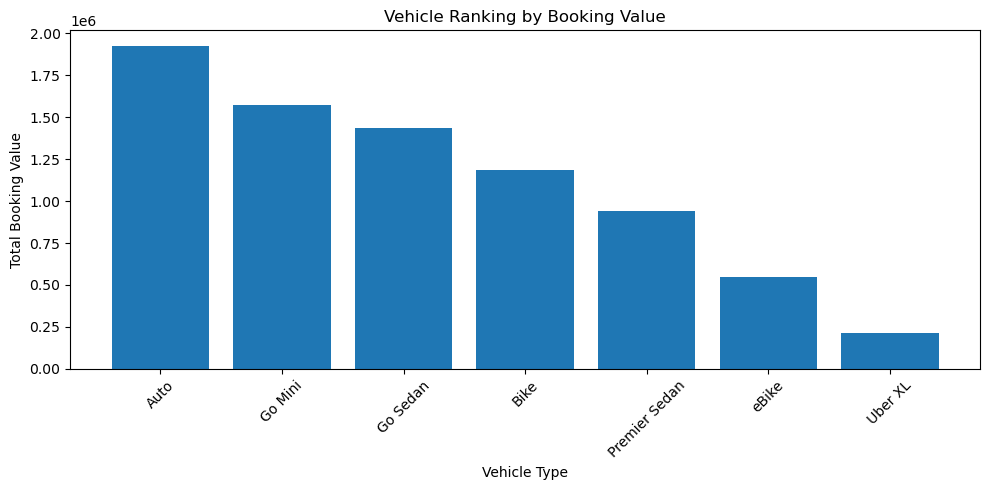

In [26]:
# Q10 Visualization

plt.figure(figsize=(10, 5))

plt.bar(
    q10_result["Vehicle Type"],
    q10_result["total_booking_value"]
)

plt.title("Vehicle Ranking by Booking Value")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Booking Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()